In [2]:
import zipfile
import os
import cv2

zip_path = "/content/archive (3).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1944


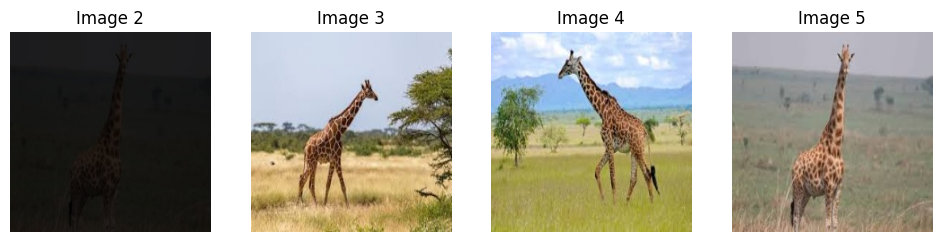

In [23]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15,5))

for i in range(1,min(5, len(images))):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img_rgb)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

In [4]:
import pandas as pd

image_details = []

for i, img in enumerate(images):
    h, w, c = img.shape

    image_details.append({
        "Image": f"Image_{i+1}",
        "Height": h,
        "Width": w,
        "Channels": c
    })

df = pd.DataFrame(image_details)

print(df.head())

# Optional: Save table
df.to_csv("image_details.csv", index=False)

     Image  Height  Width  Channels
0  Image_1     224    224         3
1  Image_2     224    224         3
2  Image_3     224    224         3
3  Image_4     224    224         3
4  Image_5     224    224         3


In [5]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224, 224))
    resized_images.append(resized)

print("Total resized images:", len(resized_images))

Total resized images: 1944


In [6]:
gray_images = []
rgb_images = []
hsv_images = []

for img in resized_images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    gray_images.append(gray)
    rgb_images.append(rgb)
    hsv_images.append(hsv)

print("Conversion completed")

Conversion completed


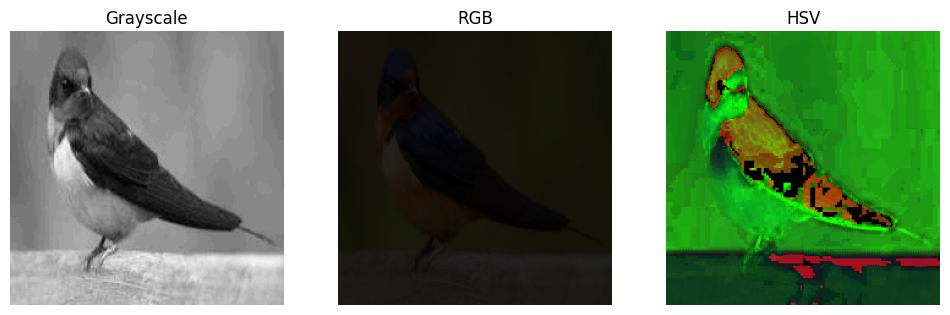

In [25]:
sample = resized_images[700]

gray = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(sample, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

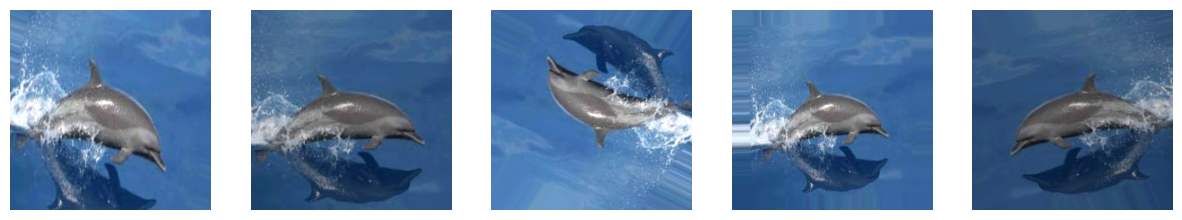

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

sample = np.expand_dims(resized_images[800], axis=0)

augmented = datagen.flow(sample, batch_size=1)

plt.figure(figsize=(15,5))

for i in range(5):
    aug_img = next(augmented)[0].astype("uint8")

    plt.subplot(1,5,i+1)
    plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.show()

In [9]:
def preprocess_image(image_path):

    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Image not found")

    # Resize
    resized = cv2.resize(img, (224, 224))

    # Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # RGB
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    # HSV
    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    # Normalize
    normalized = resized / 255.0

    return {
        "resized": resized,
        "gray": gray,
        "rgb": rgb,
        "hsv": hsv,
        "normalized": normalized
    }

In [10]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            sample_path = os.path.join(root, file)
            break

result = preprocess_image(sample_path)

print("Resized Shape:", result["resized"].shape)
print("Normalized Range:",
      result["normalized"].min(),
      result["normalized"].max())

Resized Shape: (224, 224, 3)
Normalized Range: 0.0 1.0
